# Task 1: Problem Identification
The dataset represents an **Image Classification** problem because the images are already divided into different folders such as dent, normal, scratch, and stain. Each image belongs to only one category, and the objective is to identify which category an image belongs to.

Image classification is the most suitable problem type for this dataset because the model needs to study visual patterns from the images and predict a single label. For example, if an image contains a scratch, the model should classify it under the scratch category. Similarly, images showing dents or stains should be classified into their respective categories.

This dataset does not represent object detection because there are no bounding boxes showing object locations. It is also not semantic or instance segmentation because pixel-level labeling is not provided. Therefore, image classification is the correct computer vision problem type for this dataset.

In [1]:
import zipfile

zip_path = "part_2_cnn_computer_vision.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


# TASK 2: DATASET EXPLORATION

In [2]:
# Import libraries

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Check Classes

dataset_path = "/content/dataset/part_2_cnn_computer_vision/images"

classes = os.listdir(dataset_path)

print("Classes in dataset:")
print(classes)

Classes in dataset:
['normal', 'dent', 'scratch', 'stain', '.DS_Store']


In [5]:
# Correct number of classes

classes = ['normal', 'dent', 'scratch', 'stain']

num_classes = len(classes)

print("Number of classes:", num_classes)
print("Classes are:", classes)

Number of classes: 4
Classes are: ['normal', 'dent', 'scratch', 'stain']


In [6]:
# Number of Classes

num_classes = len(classes)

print("Number of classes:", num_classes)

Number of classes: 4


In [7]:
# Number of images in each class

dataset_path = "/content/dataset/part_2_cnn_computer_vision/images"

classes = ['normal', 'dent', 'scratch', 'stain']

for category in classes:
    folder_path = os.path.join(dataset_path, category)
    total_images = len(os.listdir(folder_path))
    print(category, ":", total_images, "images")

normal : 120 images
dent : 120 images
scratch : 120 images
stain : 120 images


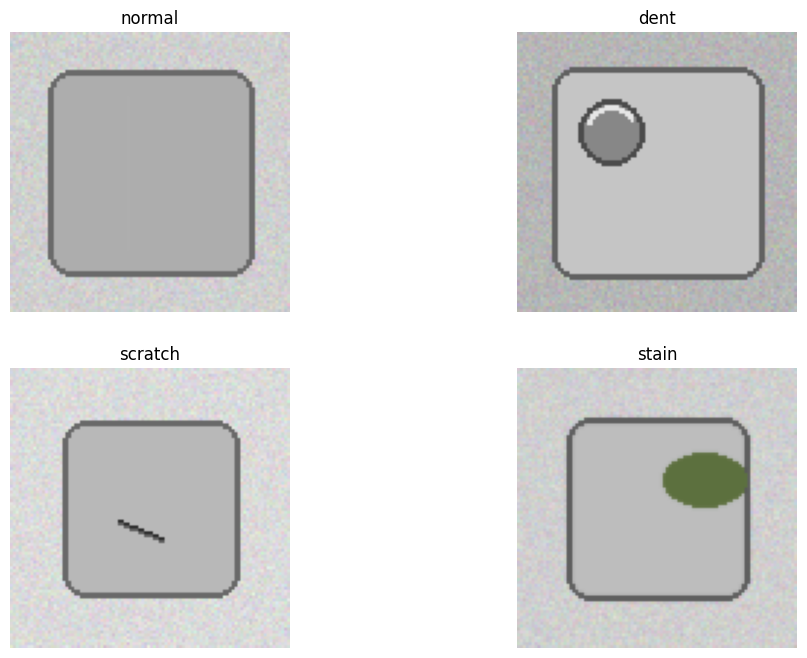

In [8]:
# Show sample images from each class

plt.figure(figsize=(12,8))

for i, category in enumerate(classes):

    folder_path = os.path.join(dataset_path, category)

    image_name = os.listdir(folder_path)[0]

    image_path = os.path.join(folder_path, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)

    plt.imshow(image)

    plt.title(category)

    plt.axis("off")

plt.show()

In [10]:
# Check image dimensions

for category in classes:

    folder_path = os.path.join(dataset_path, category)

    image_name = os.listdir(folder_path)[0]
    image_path = os.path.join(folder_path, image_name)
    image = cv2.imread(image_path)

    print(category, "image shape:", image.shape)

normal image shape: (96, 96, 3)
dent image shape: (96, 96, 3)
scratch image shape: (96, 96, 3)
stain image shape: (96, 96, 3)


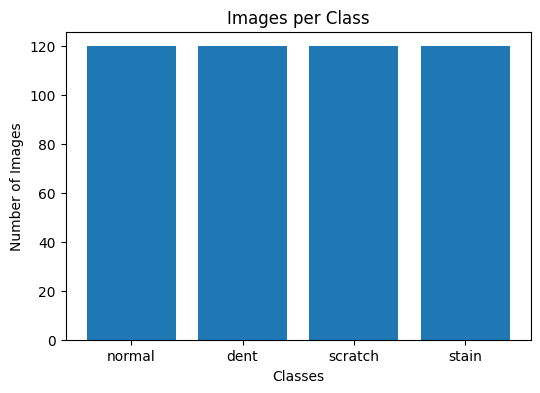

In [11]:
# Task 2 - Check dataset balance

image_count = []

for category in classes:

    folder_path = os.path.join(dataset_path, category)

    total_images = len(os.listdir(folder_path))

    image_count.append(total_images)

plt.figure(figsize=(6,4))

plt.bar(classes, image_count)

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.title("Images per Class")

plt.show()

# MARKDOWN
## Dataset Analysis

The image dataset contains **4 different classes**, which are:

- Normal  
- Dent  
- Scratch  
- Stain  

### Number of Images Per Class

- Normal → 120 images  
- Dent → 120 images  
- Scratch → 120 images  
- Stain → 120 images  

The dataset contains a total of **480 images**.

### Sample Images

Sample images from all four classes were displayed to understand the visual differences between categories. Each category has different visual characteristics which can help the CNN model learn patterns more effectively.

### Image Dimensions

The dimensions of the images are **96 × 96 pixels with 3 color channels (RGB)**. Since all images have the same size, it becomes easier to train the CNN model consistently.

### Dataset Imbalance Check

The dataset is balanced because each class contains the same number of images (**120 images each**). This balanced distribution reduces the chances of bias in prediction and helps the model learn equally from all categories.

#TASK 3: Image Preprocessing

In [12]:
# Task 3 - Image Preprocessing

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size
img_size = (96, 96)

# Batch size
batch_size = 32

# Data generator with normalization
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation data
test_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

print("Preprocessing completed successfully!")

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.
Preprocessing completed successfully!


# MARKDOWN

The image dataset was preprocessed before training the CNN model. All images were resized to 96 × 96 pixels to maintain a fixed size. Pixel values were normalized between 0 and 1 for better model learning.

The dataset was divided into training and testing (validation) sets using an 80:20 split. Data augmentation techniques such as rotation, zooming, and flipping were also applied to improve model performance and reduce overfitting.

# TASK 4 - CNN Model Creation

In [13]:
# TASK 4 - CNN Model Creation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Create CNN model
model = Sequential()

# First Convolution + Pooling Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution + Pooling Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(4, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,984,964 (15.20 MB)

 Trainable params: 3,984,964 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

# MARKDOWN
A Convolutional Neural Network (CNN) model was developed to classify images into four categories: normal, dent, scratch, and stain. The model was built using TensorFlow/Keras to learn visual patterns from the image dataset.

The CNN architecture includes multiple convolutional layers to extract important image features, followed by pooling layers to reduce image dimensions and computational complexity. The ReLU activation function was used to introduce non-linearity and improve learning performance.

After feature extraction, a flatten layer was added to convert the image data into a one-dimensional format. Dense layers were then used for classification, and a dropout layer was included to reduce overfitting. Finally, a softmax output layer was used to predict one of the four image classes.

The model was compiled using the Adam optimizer, categorical crossentropy loss function, and accuracy as the evaluation metric.

# TASK 5 - Model Training

In [14]:
# TASK 5 - Model Training

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 502ms/step - accuracy: 0.2760 - loss: 1.5797 - val_accuracy: 0.5000 - val_loss: 1.3657
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 568ms/step - accuracy: 0.4036 - loss: 1.3266 - val_accuracy: 0.4792 - val_loss: 1.2651
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 422ms/step - accuracy: 0.5625 - loss: 1.1260 - val_accuracy: 0.6146 - val_loss: 0.9738
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 600ms/step - accuracy: 0.6849 - loss: 0.8491 - val_accuracy: 0.6250 - val_loss: 0.8932
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 484ms/step - accuracy: 0.7812 - loss: 0.7309 - val_accuracy: 0.7812 - val_loss: 0.6036
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 567ms/step - accuracy: 0.8594 - loss: 0.4617 - val_accuracy: 0.7917 - val_loss: 0.4575
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 437ms/step - accuracy: 0.8542 - loss: 0.3952 - val_accuracy: 0.8229 - val_loss: 0.4424
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 399ms/step - accuracy: 0.8984 - loss: 0.3122 - val_accuracy: 0.

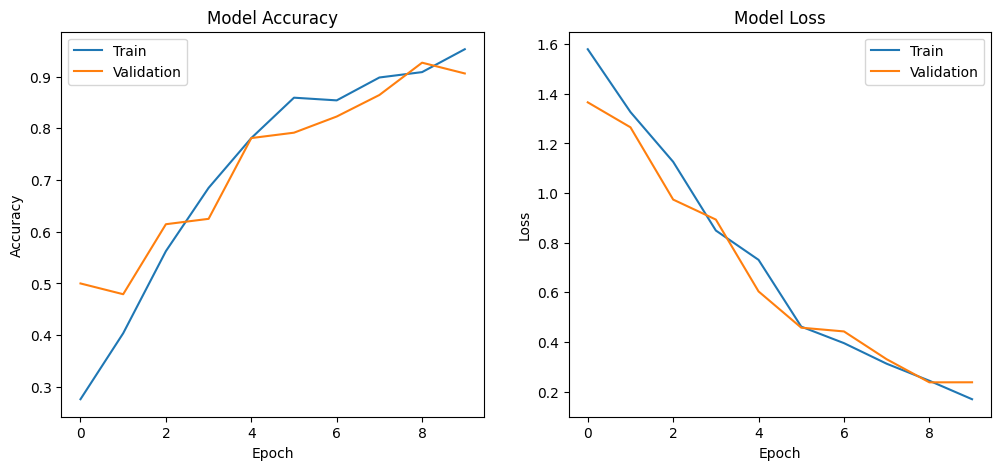

In [15]:
# Accuracy and Loss Curves

import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.savefig("accuracy_loss_curves.png")
plt.show()

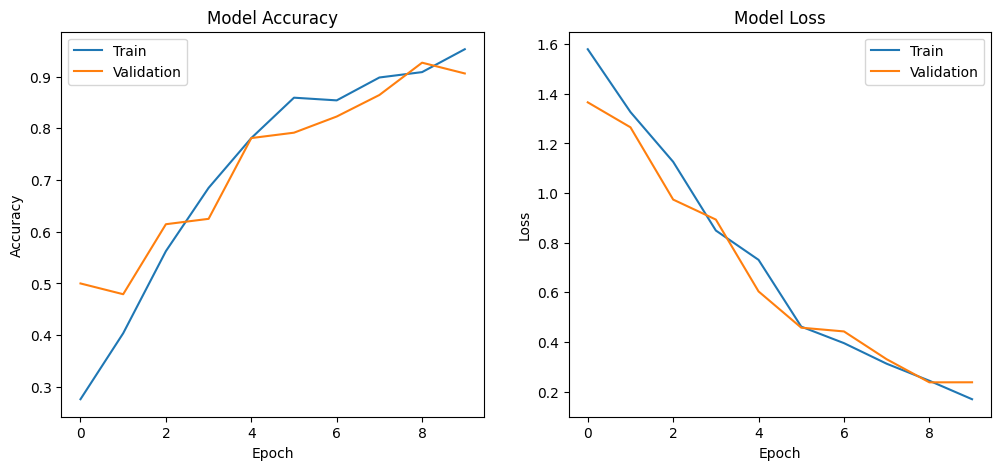

In [17]:
# Accuracy and Loss Curves

import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.savefig("accuracy_loss_curves.png")
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step


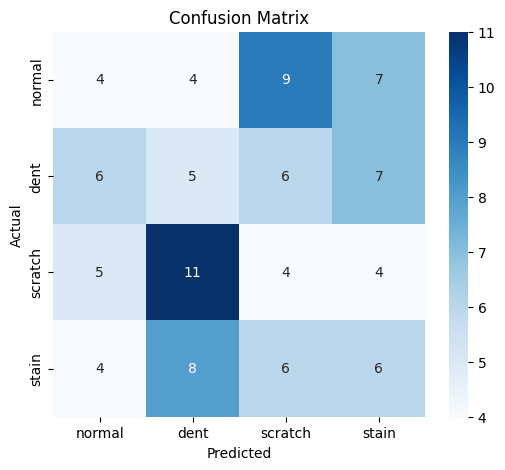

In [18]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Reset test data
test_data.reset()

# Predictions
predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# Save image
plt.savefig("confusion_matrix.png")

plt.show()

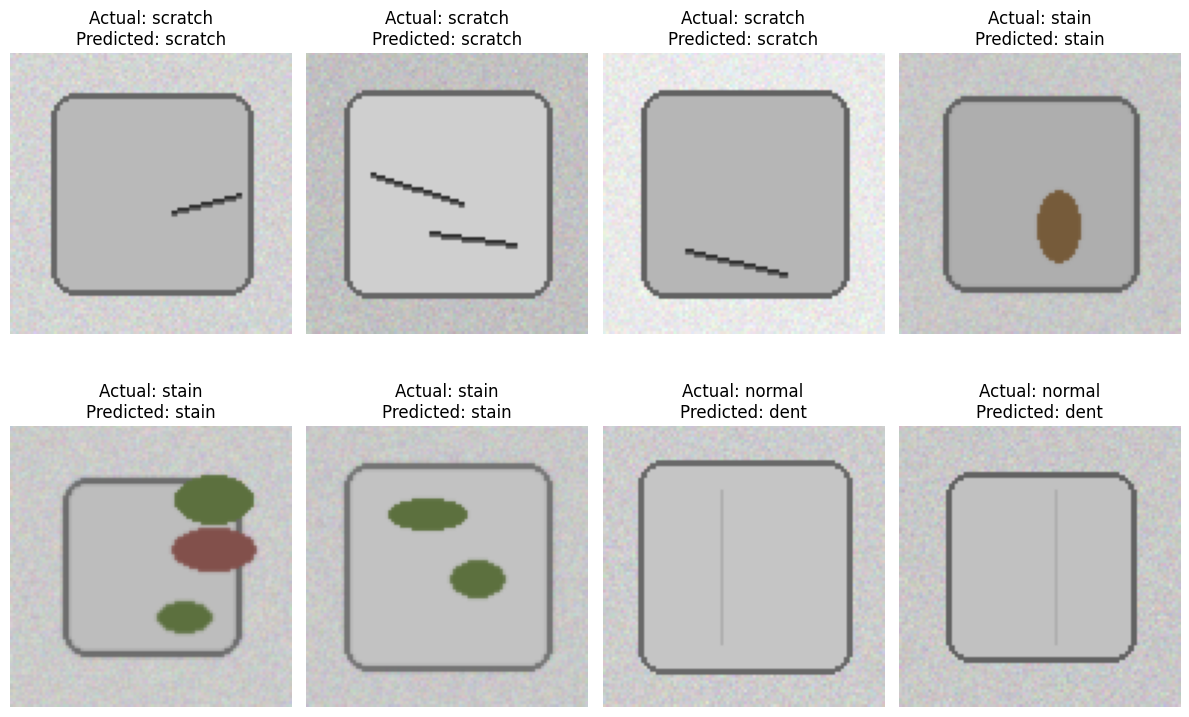

In [19]:
# Sample Predictions on Test Images

import random

plt.figure(figsize=(12,8))

for i in range(8):

    category = random.choice(classes)

    folder_path = os.path.join(dataset_path, category)

    image_name = random.choice(os.listdir(folder_path))

    image_path = os.path.join(folder_path, image_name)

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    resized_image = cv2.resize(image_rgb, img_size)
    normalized_image = resized_image / 255.0

    prediction = model.predict(np.expand_dims(normalized_image, axis=0), verbose=0)

    predicted_class = classes[np.argmax(prediction)]

    plt.subplot(2,4,i+1)
    plt.imshow(image_rgb)
    plt.title(f"Actual: {category}\nPredicted: {predicted_class}")
    plt.axis("off")

plt.tight_layout()

plt.savefig("prediction_outputs.png")

plt.show()

# MARKDOWN

The CNN model was trained using the image dataset and evaluated on validation data. Training and validation accuracy improved over epochs, while loss decreased, showing that the model learned image patterns effectively.

The model performance was analyzed using:
- Training and validation accuracy/loss
- Confusion matrix
- Sample predictions on test images